# Random Forest Classifier

El Random Forest Classifier (RFC) es un algoritmo de aprendizaje automático que utiliza un conjunto de árboles de decisión para realizar tareas de clasificación. Funciona creando múltiples árboles a partir de muestras aleatorias de datos y características, y luego combina sus predicciones mediante votación mayoritaria.

- Conjunto de Árboles de Decisión: Random Forest crea un "bosque" de árboles de decisión. Cada árbol se entrena con una muestra aleatoria de los datos y, a menudo, se utilizan subconjuntos aleatorios de características para la toma de decisiones en cada nodo.

- Votación Mayoritaria: Para la clasificación, cada árbol en el bosque emite un voto sobre la clase a la que pertenece una instancia. La clase que recibe más votos se elige como la predicción final.

- Reducción del Sobreajuste: Al promediar las predicciones de múltiples árboles, Random Forest tiende a ser menos propenso al sobreajuste en comparación con un solo árbol de decisión.

- Manejo de Datos Faltantes: Random Forest puede manejar datos faltantes de manera efectiva y puede proporcionar estimaciones de la importancia de las características, lo que ayuda a entender qué variables son más relevantes para las predicciones.

- Escalabilidad: Es un algoritmo que puede escalar bien con grandes conjuntos de datos y puede ser utilizado en problemas de alta dimensionalidad.

In [ ]:
# Instalar librerías necesarias (Solo ejecutar si no están instaladas)
from IPython.utils import io
import tqdm.notebook

total = 100
with tqdm.notebook.tqdm(total=total) as pbar:
    with io.capture_output() as captured:
        # Instalar rdkit
        !pip -q install rdkit.pypi==2021.9.4
        pbar.update(20)
        # Instalar Pillow
        !pip -q install Pillow
        pbar.update(40)
        # Instalar molplotly
        !pip install molplotly
        pbar.update(60)
        # Instalar jupyter-dash
        !pip install jupyter-dash
        pbar.update(80)
        # Instalar el diseño de aplicación dash
        !pip install dash-bootstrap-components
        pbar.update(100)

  0%|          | 0/100 [00:00<?, ?it/s]

In [ ]:
# Importar librerías
import pandas as pd
from rdkit import Chem
from rdkit.Chem import Descriptors
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Set de Datos

Partimnos de un set de datos (test) que contiene 51 compuestos reportados con actividad senoterapeutica obtenidos de https://doi.org/10.1111/febs.16350

El segundo set de datos consta de 50 compuestos con etiqueta de toxicos obtenidos de ChEMBL por medio de API.
Para el modelo de Machine Learning se usara de la siguiente manera, los datos fueron binados y ordenados en datos de prueba y entrenamiento.

0= compuestos NO senoterapeuticos (prueba)

1= compuestos senoterapeuticos reportados en doi: 10.1111/febs.16350
 (test)

In [ ]:
# Leer bases de datos
datos = "/content/drive/MyDrive/Doctorado_Santiago/Set de Datos 2/Objetivo 4/0_DATA/Concatenadas_csv.csv"
datos = pd.read_csv(datos)

In [ ]:
# Agregar una columna de índices
datos['Index'] = datos.index

In [ ]:
datos.columns

Index(['Name', 'SMILE', 'Total Molweight', 'Monoisotopic Mass', 'cLogP',
       'cLogS', 'H-Acceptors', 'H-Donors', 'Total Surface Area',
       'Relative PSA', 'Polar Surface Area', 'Druglikeness', 'Shape Index',
       'Molecular Flexibility', 'Molecular Complexity', 'Fragments',
       'Non-H Atoms', 'Non-C/H Atoms', 'Metal-Atoms', 'Electronegative Atoms',
       'Stereo Centers', 'Rotatable Bonds', 'Rings Closures', 'Aromatic Atoms',
       'sp3-Atoms', 'Symmetric atoms', 'Small Rings', 'Carbo-Rings',
       'Hetero-Rings', 'Saturated Rings', 'Non-Aromatic Rings',
       'Aromatic Rings', 'Saturated Carbo-Rings', 'Non-Aromatic Carbo-Rings',
       'Carbo-Aromatic Rings', 'Saturated Hetero-Rings',
       'Non-Aromatic Hetero-Rings', 'Hetero-Aromatic Rings', 'Amides',
       'Amines', 'Alkyl-Amines', 'Aromatic Amines', 'Aromatic Nitrogens',
       'Basic Nitrogens', 'Acidic Oxygens', 'DataBase', 'Senotherapeutic',
       'Index'],
      dtype='object')

In [ ]:
datos

,Name,SMILE,Total Molweight,Monoisotopic Mass,cLogP,cLogS,H-Acceptors,H-Donors,Total Surface Area,Relative PSA,...,Amides,Amines,Alkyl-Amines,Aromatic Amines,Aromatic Nitrogens,Basic Nitrogens,Acidic Oxygens,DataBase,Senotherapeutic,Index
0,Ferric nitrilotriacetate,C(C(=O)[O-])N(CC(=O)[O-])CC(=O)[O-].[Fe+3],243.960,191.042989,-3.8594,0.868,7,3,137.38,0.59667,...,0,1,1,0,0,1,3,NoSenotherapeutic,0,0
1,Nitrilotriacetic acid,C(C(=O)O)N(CC(=O)O)CC(=O)O,191.138,191.042989,-3.8594,0.868,7,3,137.38,0.59667,...,0,1,1,0,0,1,3,NoSenotherapeutic,0,1
2,Oleuropein aglycone,C/C=C/1\[C@@H](C(=CO[C@H]1O)C(=O)OC)CC(=O)OCCC...,378.376,378.131470,1.5247,-2.068,8,3,284.53,0.33522,...,0,0,0,0,0,0,0,Senotherapeutic,1,2
3,Rapamycin,C[C@@H]1CC[C@H]2C[C@@H](/C(=C/C=C/C=C/[C@H](C[...,914.182,913.555144,6.5106,-6.713,14,3,716.91,0.22046,...,1,0,0,0,0,0,0,Senotherapeutic,1,3
4,KU-60019,C[C@@H]1CN(C[C@@H](O1)C)CC(=O)NC2=CC3=C(C=C2)S...,547.674,547.214092,4.2047,-5.834,8,1,403.09,0.22856,...,1,1,1,0,0,1,0,Senotherapeutic,1,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99,TICRYNAFEN,O=C(O)COc1ccc(C(=O)c2cccs2)c(Cl)c1Cl,331.175,329.952034,2.9282,-4.991,4,1,225.41,0.30850,...,0,0,0,0,0,0,1,NoSenotherapeutic,0,99
100,BENDAZAC,O=C(O)COc1nn(Cc2ccccc2)c2ccccc12,282.298,282.100443,1.8077,-2.992,5,1,217.20,0.24853,...,0,0,0,0,2,0,1,NoSenotherapeutic,0,100
101,EF-24 (curcumin analogue),O=C1/C(=C/c2ccccc2F)CNC/C1=C\c1ccccc1F,311.330,311.112170,3.7321,-4.193,2,1,238.37,0.10278,...,0,1,1,0,0,1,0,Senotherapeutic,1,101
102,Fisetin,O=c1c(O)c(-c2ccc(O)c(O)c2)oc2cc(O)ccc12,286.238,286.047740,1.8359,-2.787,6,4,195.59,0.38570,...,0,0,0,0,0,0,0,Senotherapeutic,1,102


In [ ]:
# Información del dataset
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104 entries, 0 to 103
Data columns (total 48 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Name                       104 non-null    object 
 1   SMILE                      104 non-null    object 
 2   Total Molweight            104 non-null    float64
 3   Monoisotopic Mass          104 non-null    float64
 4   cLogP                      104 non-null    float64
 5   cLogS                      104 non-null    float64
 6   H-Acceptors                104 non-null    int64  
 7   H-Donors                   104 non-null    int64  
 8   Total Surface Area         104 non-null    float64
 9   Relative PSA               104 non-null    float64
 10  Polar Surface Area         104 non-null    float64
 11  Druglikeness               104 non-null    float64
 12  Shape Index                104 non-null    float64
 13  Molecular Flexibility      104 non-null    float64

In [ ]:
# Separar las las columnas de las variables predictorias (X) de la columna que contiene la variable a predecir (Y)
# PODEMOS UTILIZAR UNICAMENTE COLUMNAS (DESCRIPTORES) DE INTERES PARA ENTRENAR EL MODELO Y NO CAER EN SOBREAJUSTE.
columnas_interes = [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44]
X = datos.iloc[:, columnas_interes]
y = datos.iloc[:, 46]

In [ ]:
# Separar datos en conjuntos de entrenamiento y prueba

#indicamos que se partan los datos en un 75% para la entrenamiento y 25% para prueba,
#el valor de random_state=42 nos indica que el algoritmo utilizará los mismos datos de entrenamiento y prueba lo que nos dara reproducibilidad

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.75, random_state=42)


#Creacion del modelo de Random Forest

Random Forest Classifier es una herramienta poderosa y versátil en el campo del aprendizaje automático, especialmente útil cuando se trabaja con datos complejos y de alta dimensionalidad.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
# Creación del modelo Random Forest
modelo_rf = RandomForestClassifier(n_estimators=5, random_state=42)

In [ ]:
# Entrenar el modelo
arbol_senos = modelo_rf.fit(X_train, y_train)


In [ ]:
# Predecir la respuesta en base a las etiquetas para todos los datos
y_pred_all = arbol_senos.predict(X)


# Resultados

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

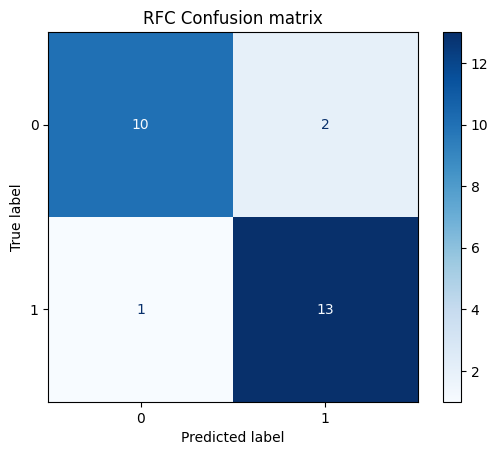

In [ ]:
# Generar y visualizar la matriz de confusión
conf_matrix = confusion_matrix(y_test, arbol_senos.predict(X_test))
class_names = y_test.unique()
disp = ConfusionMatrixDisplay(conf_matrix, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues)
plt.title('RFC Confusion matrix')
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.show()

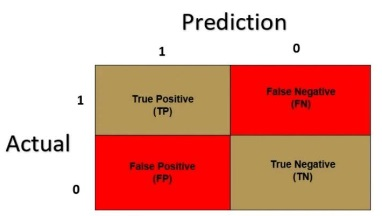

https://dx.doi.org/10.21123/bsj.2023.9010

In [ ]:
tp = 10
fp = 1
fn = 2
tn = 13


### Accurucy (precisión)

Es el porcentaje de predicciones correctas sobre el total de predicciones realizadas.

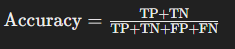

donde:

TP: Verdaderos positivos

TN: Verdaderos negativos

FP: Falsos positivos

FN: Falsos negativos

In [ ]:
# Mostrar la precisión del modelo en el conjunto de prueba
from sklearn.metrics import accuracy_score
accuracy = (tp + tn) / (tp + fp + fn + tn)
print("Accuracy:", accuracy)


Accuracy: 0.8846153846153846


### Especificidad

 Es la capacidad del modelo para identificar correctamente las muestras negativas.

 También se conoce como tasa de verdaderos negativos.

 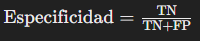

In [ ]:
from sklearn.metrics import confusion_matrix
# Calculate the specificity score
specificity = tn / (tn + fp)
print("Specificity:", specificity)

Specificity: 0.9285714285714286


# Kappa
Mide el grado de concordancia entre las predicciones del modelo y las etiquetas reales, teniendo en cuenta el acuerdo que se podría obtener por azar.


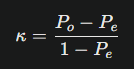

In [ ]:
from sklearn.metrics import confusion_matrix

# Cálculo de P_o
P_o = (tp + tn) / (tp + tn + fp + fn)

# Cálculo de P_e
P_e = ((tp + fp) / (tp + tn + fp + fn)) * ((tp + fn) / (tp + tn + fp + fn)) + \
       ((tn + fn) / (tp + tn + fp + fn)) * ((tn + fp) / (tp + tn + fp + fn))

# Cálculo de Kappa
kappa = (P_o - P_e) / (1 - P_e)

print("Kappa:", kappa)

Kappa: 0.7664670658682634


En el contexto de machine learning, la precisión (precision en inglés) es una métrica utilizada para evaluar la calidad de un modelo de clasificación, especialmente en problemas de clasificación binaria. La precisión se define como la proporción de verdaderos positivos (TP, por sus siglas en inglés) sobre el total de predicciones positivas realizadas por el modelo.


In [ ]:
Precision = tp / (tp + fp)
Precision

0.9090909090909091

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Predicciones sobre el conjunto de prueba
y_pred = arbol_senos.predict(X_test)

# Calcular Precisión, Recall y F1 Score
precision = precision_score(y_test, y_pred, average='binary')  # Para clasificación binaria
recall = recall_score(y_test, y_pred, average='binary')      # Para clasificación binaria
f1 = f1_score(y_test, y_pred, average='binary')              # Para clasificación binaria

# Mostrar los resultados
print("Precisión:", precision)
print("Recall:", recall)
print("F1 Score:", f1)


Precisión: 0.8666666666666667
Recall: 0.9285714285714286
F1 Score: 0.896551724137931


In [ ]:
# Crear un nuevo dataframe con todos los resultados
resultados_arbol = datos.copy()
resultados_arbol['Prediction'] = y_pred_all


In [ ]:
resultados_arbol

,Name,SMILE,Total Molweight,Monoisotopic Mass,cLogP,cLogS,H-Acceptors,H-Donors,Total Surface Area,Relative PSA,...,Amines,Alkyl-Amines,Aromatic Amines,Aromatic Nitrogens,Basic Nitrogens,Acidic Oxygens,DataBase,Senotherapeutic,Index,Prediction
0,Ferric nitrilotriacetate,C(C(=O)[O-])N(CC(=O)[O-])CC(=O)[O-].[Fe+3],243.960,191.042989,-3.8594,0.868,7,3,137.38,0.59667,...,1,1,0,0,1,3,NoSenotherapeutic,0,0,0
1,Nitrilotriacetic acid,C(C(=O)O)N(CC(=O)O)CC(=O)O,191.138,191.042989,-3.8594,0.868,7,3,137.38,0.59667,...,1,1,0,0,1,3,NoSenotherapeutic,0,1,0
2,Oleuropein aglycone,C/C=C/1\[C@@H](C(=CO[C@H]1O)C(=O)OC)CC(=O)OCCC...,378.376,378.131470,1.5247,-2.068,8,3,284.53,0.33522,...,0,0,0,0,0,0,Senotherapeutic,1,2,1
3,Rapamycin,C[C@@H]1CC[C@H]2C[C@@H](/C(=C/C=C/C=C/[C@H](C[...,914.182,913.555144,6.5106,-6.713,14,3,716.91,0.22046,...,0,0,0,0,0,0,Senotherapeutic,1,3,1
4,KU-60019,C[C@@H]1CN(C[C@@H](O1)C)CC(=O)NC2=CC3=C(C=C2)S...,547.674,547.214092,4.2047,-5.834,8,1,403.09,0.22856,...,1,1,0,0,1,0,Senotherapeutic,1,4,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99,TICRYNAFEN,O=C(O)COc1ccc(C(=O)c2cccs2)c(Cl)c1Cl,331.175,329.952034,2.9282,-4.991,4,1,225.41,0.30850,...,0,0,0,0,0,1,NoSenotherapeutic,0,99,0
100,BENDAZAC,O=C(O)COc1nn(Cc2ccccc2)c2ccccc12,282.298,282.100443,1.8077,-2.992,5,1,217.20,0.24853,...,0,0,0,2,0,1,NoSenotherapeutic,0,100,0
101,EF-24 (curcumin analogue),O=C1/C(=C/c2ccccc2F)CNC/C1=C\c1ccccc1F,311.330,311.112170,3.7321,-4.193,2,1,238.37,0.10278,...,1,1,0,0,1,0,Senotherapeutic,1,101,1
102,Fisetin,O=c1c(O)c(-c2ccc(O)c(O)c2)oc2cc(O)ccc12,286.238,286.047740,1.8359,-2.787,6,4,195.59,0.38570,...,0,0,0,0,0,0,Senotherapeutic,1,102,1


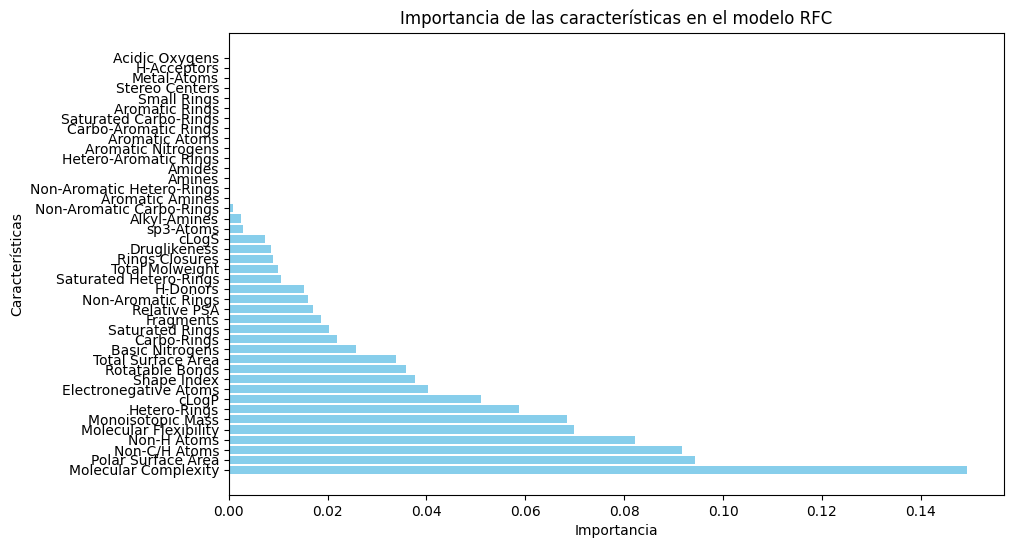

In [ ]:
# Obtener las importancias de las características
importancia_features = arbol_senos.feature_importances_

# Crear un DataFrame para las importancias
importancia_df = pd.DataFrame({
    'Característica': X.columns,
    'Importancia': importancia_features
})

# Ordenar las importancias de mayor a menor
importancia_df = importancia_df.sort_values(by='Importancia', ascending=False)

# Graficar las importancias
plt.figure(figsize=(10, 6))
plt.barh(importancia_df['Característica'], importancia_df['Importancia'], color='skyblue')
plt.xlabel('Importancia')
plt.ylabel('Características')
plt.title('Importancia de las características en el modelo RFC')
plt.show()


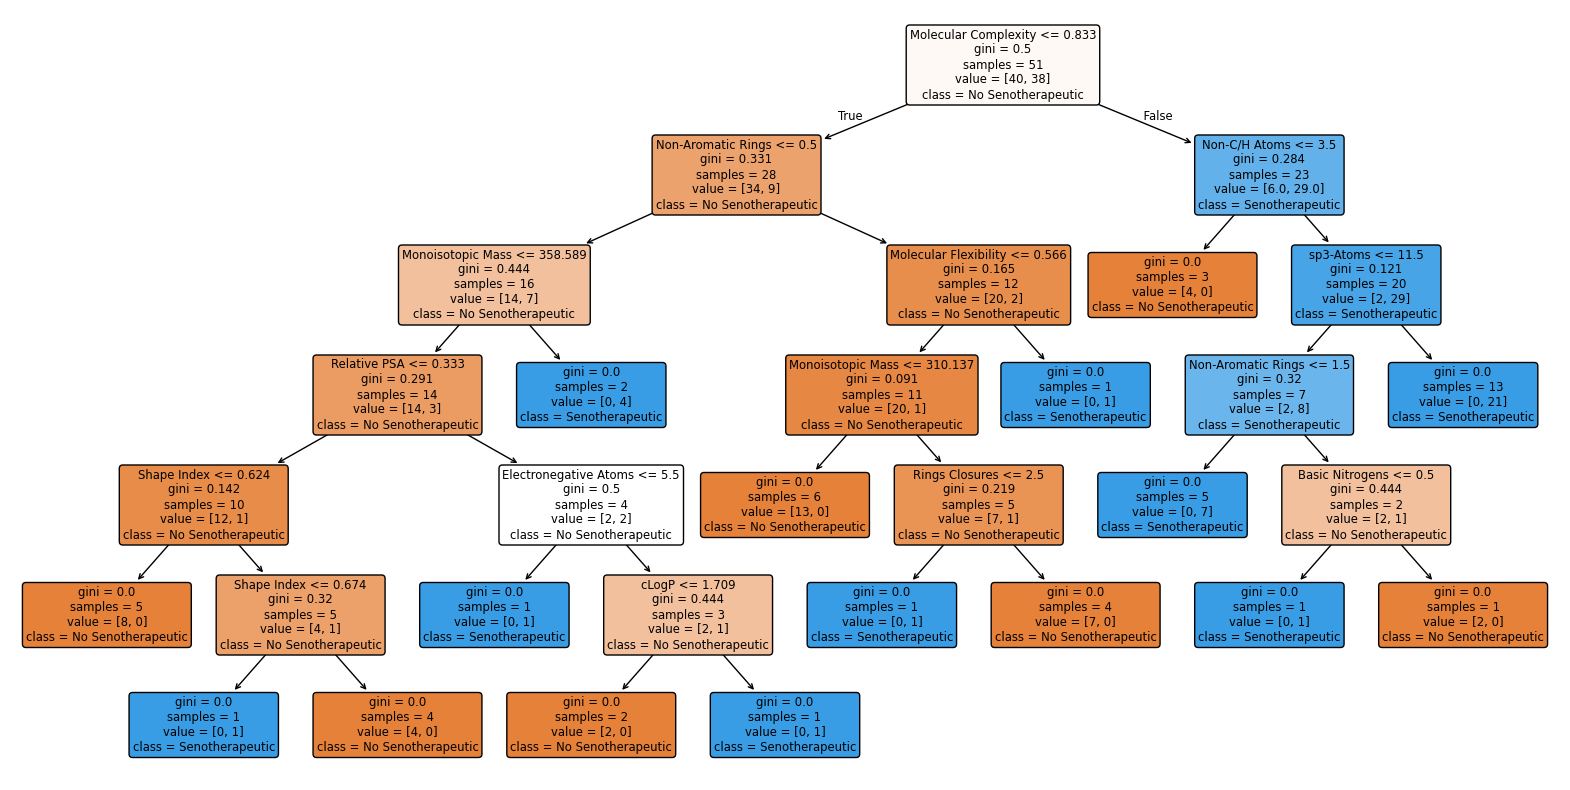

In [ ]:
# visualizar mi arbol de decision de randomfores que se llama arbol_senos

from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))
plot_tree(arbol_senos.estimators_[0],
          feature_names=X.columns,
          class_names=['No Senotherapeutic', 'Senotherapeutic'],
          filled=True,
          rounded=True)
plt.show()


In [ ]:
# Guardar los resultados en un archivo CSV
#resultados_arbol.to_csv('resultados_arbol.csv', index=False)

#Predicciones

De los datos obtenidos en coconut data base.

COCONUT es una plataforma dedicada a recopilar y proporcionar información sobre propiedades, aplicaciones, beneficios para la salud de productos naturales. Esta base de datos cuenta con mas de 400 mil compuestos.

In [ ]:
# Cargar la base de datos obtenida en CTD
ctd_data = pd.read_csv("/content/drive/MyDrive/Doctorado_Santiago/Set de Datos 2/Objetivo 4/0_DATA/CTD_curado.csv")

In [ ]:
ctd_data.dropna(inplace=True)

In [ ]:
ctd_data.columns

Index(['GeneSymbol', 'SMILES', 'ChemicalName', 'Interaction',
       'InteractionActions', 'Total Molweight', 'Molweight',
       'Monoisotopic Mass', 'cLogP', 'cLogS', 'H-Acceptors', 'H-Donors',
       'Total Surface Area', 'Relative PSA', 'Polar Surface Area',
       'Druglikeness', 'Mutagenic', 'Tumorigenic', 'Reproductive Effective',
       'Irritant', 'Shape Index', 'Molecular Flexibility',
       'Molecular Complexity', 'Fragments', 'Non-H Atoms', 'Non-C/H Atoms',
       'Metal-Atoms', 'Electronegative Atoms', 'Stereo Centers',
       'Rotatable Bonds', 'Rings Closures', 'Aromatic Atoms', 'sp3-Atoms',
       'Small Rings', 'Carbo-Rings', 'Hetero-Rings', 'Saturated Rings',
       'Non-Aromatic Rings', 'Aromatic Rings', 'Saturated Carbo-Rings',
       'Non-Aromatic Carbo-Rings', 'Carbo-Aromatic Rings',
       'Saturated Hetero-Rings', 'Non-Aromatic Hetero-Rings',
       'Hetero-Aromatic Rings', 'Amides', 'Amines', 'Alkyl-Amines',
       'Aromatic Amines', 'Aromatic Nitrogens', 'Bas

In [ ]:
ctd_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54401 entries, 0 to 54400
Data columns (total 52 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   GeneSymbol                 54401 non-null  object 
 1   SMILES                     54401 non-null  object 
 2   ChemicalName               54401 non-null  object 
 3   Interaction                54401 non-null  object 
 4   InteractionActions         54401 non-null  object 
 5   Total Molweight            54401 non-null  float64
 6   Molweight                  54401 non-null  float64
 7   Monoisotopic Mass          54401 non-null  float64
 8   cLogP                      54401 non-null  float64
 9   cLogS                      54401 non-null  float64
 10  H-Acceptors                54401 non-null  int64  
 11  H-Donors                   54401 non-null  int64  
 12  Total Surface Area         54401 non-null  float64
 13  Relative PSA               54401 non-null  flo

In [ ]:
# Preprocesar los datos de COCONUT
# Asegúrate de que coconut_data tenga las mismas columnas que usaste para entrenar el modelo
ctd_features = ctd_data.iloc[:, [5, 7, 8, 9, 10, 11, 12, 13, 14, 15, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51]]

In [ ]:
# Utilizar el modelo para hacer predicciones
ctd_predictions = arbol_senos.predict(ctd_features)

In [ ]:
# Añadir las predicciones a tu DataFrame de COCONUT
ctd_data['Prediccion'] = ctd_predictions

In [ ]:
ctd_data

,GeneSymbol,SMILES,ChemicalName,Interaction,InteractionActions,Total Molweight,Molweight,Monoisotopic Mass,cLogP,cLogS,...,Non-Aromatic Hetero-Rings,Hetero-Aromatic Rings,Amides,Amines,Alkyl-Amines,Aromatic Amines,Aromatic Nitrogens,Basic Nitrogens,Acidic Oxygens,Prediccion
0,AKT1,[B-]12(OC3C(C(OC3(O1)CO)CO)O)OC4C(C(OC4(O2)CO)...,calcium fructoborate,calcium fructoborate affects the expression of...,affects^expression,774.258,367.0900,367.104785,-5.2466,2.630,...,4,0,0,0,0,0,0,0,0,1
1,PTEN,[B-]12(OC3C(C(OC3(O1)CO)CO)O)OC4C(C(OC4(O2)CO)...,calcium fructoborate,calcium fructoborate results in increased expr...,increases^expression,774.258,367.0900,367.104785,-5.2466,2.630,...,4,0,0,0,0,0,0,0,0,1
2,EIF4EBP1,[B-]12(OC3C(C(OC3(O1)CO)CO)O)OC4C(C(OC4(O2)CO)...,calcium fructoborate,calcium fructoborate affects the expression of...,affects^expression,774.258,367.0900,367.104785,-5.2466,2.630,...,4,0,0,0,0,0,0,0,0,1
3,TSC2,[B-]12(OC3C(C(OC3(O1)CO)CO)O)OC4C(C(OC4(O2)CO)...,calcium fructoborate,calcium fructoborate results in increased expr...,increases^expression,774.258,367.0900,367.104785,-5.2466,2.630,...,4,0,0,0,0,0,0,0,0,1
4,TP53,[Be+2].[O-]S(=O)(=O)[O-],beryllium sulfate,beryllium sulfate promotes the reaction [TP53 ...,affects^binding|increases^reaction,105.074,98.0779,97.967380,-3.4103,1.524,...,0,0,0,0,0,0,0,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54396,RELA,S1[As]2S[As]3[As]1S[As]2S3,tetraarsenic tetrasulfide,tetraarsenic tetrasulfide results in decreased...,decreases^expression,427.952,427.9520,427.574656,0.0000,-0.530,...,6,0,0,0,0,0,0,0,0,0
54397,RELA,S1[As]2S[As]3[As]1S[As]2S3,tetraarsenic tetrasulfide,tetraarsenic tetrasulfide results in decreased...,decreases^expression,427.952,427.9520,427.574656,0.0000,-0.530,...,6,0,0,0,0,0,0,0,0,0
54398,MTOR,S1[As]2S[As]3[As]1S[As]2S3,tetraarsenic tetrasulfide,tetraarsenic tetrasulfide promotes the reactio...,decreases^expression|increases^reaction,427.952,427.9520,427.574656,0.0000,-0.530,...,6,0,0,0,0,0,0,0,0,0
54399,EIF4EBP1,S1[As]2S[As]3[As]1S[As]2S3,tetraarsenic tetrasulfide,tetraarsenic tetrasulfide promotes the reactio...,decreases^expression|increases^reaction,427.952,427.9520,427.574656,0.0000,-0.530,...,6,0,0,0,0,0,0,0,0,0


In [ ]:
# Guardar los resultados en un archivo CSV
ctd_data.to_csv('Sen_ctd_random_forest.csv', index=False)

In [ ]:
# Analizar los resultados
# Contar cuántos compuestos se predicen como activos o inactivos
print(ctd_data['Prediccion'].value_counts())


Prediccion
0    28661
1    25740
Name: count, dtype: int64


In [ ]:
# Filtrar los compuestos predichos como activos
compuestos_activos = ctd_data[ctd_data['Prediccion'] == 1]

In [ ]:
# Mostrar los primeros compuestos predichos como activos
compuestos_activos.head(10)

,GeneSymbol,SMILES,ChemicalName,Interaction,InteractionActions,Total Molweight,Molweight,Monoisotopic Mass,cLogP,cLogS,...,Non-Aromatic Hetero-Rings,Hetero-Aromatic Rings,Amides,Amines,Alkyl-Amines,Aromatic Amines,Aromatic Nitrogens,Basic Nitrogens,Acidic Oxygens,Prediccion
0,AKT1,[B-]12(OC3C(C(OC3(O1)CO)CO)O)OC4C(C(OC4(O2)CO)...,calcium fructoborate,calcium fructoborate affects the expression of...,affects^expression,774.258,367.0900,367.104785,-5.2466,2.630,...,4,0,0,0,0,0,0,0,0,1
1,PTEN,[B-]12(OC3C(C(OC3(O1)CO)CO)O)OC4C(C(OC4(O2)CO)...,calcium fructoborate,calcium fructoborate results in increased expr...,increases^expression,774.258,367.0900,367.104785,-5.2466,2.630,...,4,0,0,0,0,0,0,0,0,1
2,EIF4EBP1,[B-]12(OC3C(C(OC3(O1)CO)CO)O)OC4C(C(OC4(O2)CO)...,calcium fructoborate,calcium fructoborate affects the expression of...,affects^expression,774.258,367.0900,367.104785,-5.2466,2.630,...,4,0,0,0,0,0,0,0,0,1
3,TSC2,[B-]12(OC3C(C(OC3(O1)CO)CO)O)OC4C(C(OC4(O2)CO)...,calcium fructoborate,calcium fructoborate results in increased expr...,increases^expression,774.258,367.0900,367.104785,-5.2466,2.630,...,4,0,0,0,0,0,0,0,0,1
4,TP53,[Be+2].[O-]S(=O)(=O)[O-],beryllium sulfate,beryllium sulfate promotes the reaction [TP53 ...,affects^binding|increases^reaction,105.074,98.0779,97.967380,-3.4103,1.524,...,0,0,0,0,0,0,0,0,2,1
5,TP53,[Be+2].[O-]S(=O)(=O)[O-],beryllium sulfate,beryllium sulfate results in increased express...,increases^expression,105.074,98.0779,97.967380,-3.4103,1.524,...,0,0,0,0,0,0,0,0,2,1
6,CDKN2A,[Be+2].[O-]S(=O)(=O)[O-],beryllium sulfate,beryllium sulfate results in increased express...,increases^expression,105.074,98.0779,97.967380,-3.4103,1.524,...,0,0,0,0,0,0,0,0,2,1
7,CDKN2A,[Be+2].[O-]S(=O)(=O)[O-],beryllium sulfate,beryllium sulfate results in increased express...,increases^expression,105.074,98.0779,97.967380,-3.4103,1.524,...,0,0,0,0,0,0,0,0,2,1
8,CDKN1A,[Be+2].[O-]S(=O)(=O)[O-],beryllium sulfate,beryllium sulfate promotes the reaction [TP53 ...,affects^binding|increases^reaction,105.074,98.0779,97.967380,-3.4103,1.524,...,0,0,0,0,0,0,0,0,2,1
9,CDKN1A,[Be+2].[O-]S(=O)(=O)[O-],beryllium sulfate,beryllium sulfate results in increased express...,increases^expression,105.074,98.0779,97.967380,-3.4103,1.524,...,0,0,0,0,0,0,0,0,2,1


In [ ]:
compuestos_activos

,GeneSymbol,SMILES,ChemicalName,Interaction,InteractionActions,Total Molweight,Molweight,Monoisotopic Mass,cLogP,cLogS,...,Non-Aromatic Hetero-Rings,Hetero-Aromatic Rings,Amides,Amines,Alkyl-Amines,Aromatic Amines,Aromatic Nitrogens,Basic Nitrogens,Acidic Oxygens,Prediccion
0,AKT1,[B-]12(OC3C(C(OC3(O1)CO)CO)O)OC4C(C(OC4(O2)CO)...,calcium fructoborate,calcium fructoborate affects the expression of...,affects^expression,774.258,367.0900,367.104785,-5.2466,2.630,...,4,0,0,0,0,0,0,0,0,1
1,PTEN,[B-]12(OC3C(C(OC3(O1)CO)CO)O)OC4C(C(OC4(O2)CO)...,calcium fructoborate,calcium fructoborate results in increased expr...,increases^expression,774.258,367.0900,367.104785,-5.2466,2.630,...,4,0,0,0,0,0,0,0,0,1
2,EIF4EBP1,[B-]12(OC3C(C(OC3(O1)CO)CO)O)OC4C(C(OC4(O2)CO)...,calcium fructoborate,calcium fructoborate affects the expression of...,affects^expression,774.258,367.0900,367.104785,-5.2466,2.630,...,4,0,0,0,0,0,0,0,0,1
3,TSC2,[B-]12(OC3C(C(OC3(O1)CO)CO)O)OC4C(C(OC4(O2)CO)...,calcium fructoborate,calcium fructoborate results in increased expr...,increases^expression,774.258,367.0900,367.104785,-5.2466,2.630,...,4,0,0,0,0,0,0,0,0,1
4,TP53,[Be+2].[O-]S(=O)(=O)[O-],beryllium sulfate,beryllium sulfate promotes the reaction [TP53 ...,affects^binding|increases^reaction,105.074,98.0779,97.967380,-3.4103,1.524,...,0,0,0,0,0,0,0,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54363,STAT3,OO.OO.OO.[O-][V](=O)([O-])[O-].[Na+].[Na+].[Na+],pervanadate,pervanadate inhibits the reaction [Capsaicin r...,decreases^activity|decreases^phosphorylation|d...,285.950,117.9620,117.947097,0.3317,3.280,...,0,0,0,0,0,0,0,0,0,1
54364,STAT3,OO.OO.OO.[O-][V](=O)([O-])[O-].[Na+].[Na+].[Na+],pervanadate,pervanadate inhibits the reaction [Emodin resu...,decreases^activity|decreases^phosphorylation|d...,285.950,117.9620,117.947097,0.3317,3.280,...,0,0,0,0,0,0,0,0,0,1
54365,STAT3,OO.OO.OO.[O-][V](=O)([O-])[O-].[Na+].[Na+].[Na+],pervanadate,pervanadate inhibits the reaction [geranylnari...,decreases^phosphorylation|decreases^reaction,285.950,117.9620,117.947097,0.3317,3.280,...,0,0,0,0,0,0,0,0,0,1
54366,STAT3,OO.OO.OO.[O-][V](=O)([O-])[O-].[Na+].[Na+].[Na+],pervanadate,pervanadate inhibits the reaction [tubocapseno...,decreases^phosphorylation|decreases^reaction,285.950,117.9620,117.947097,0.3317,3.280,...,0,0,0,0,0,0,0,0,0,1


In [ ]:
# Guardar los resultados positivos en un archivo CSV
compuestos_activos.to_csv('Positivos_Sen_ctd_random_forest.csv', index=False)

# Curva ROC del modelo

La curva ROC (Receiver Operating Characteristic) es una herramienta gráfica para evaluar el rendimiento de un modelo de clasificación binaria. Muestra la relación entre la tasa de verdaderos positivos (sensibilidad) y la tasa de falsos positivos (1 - especificidad) a medida que varía el umbral de decisión del clasificador.

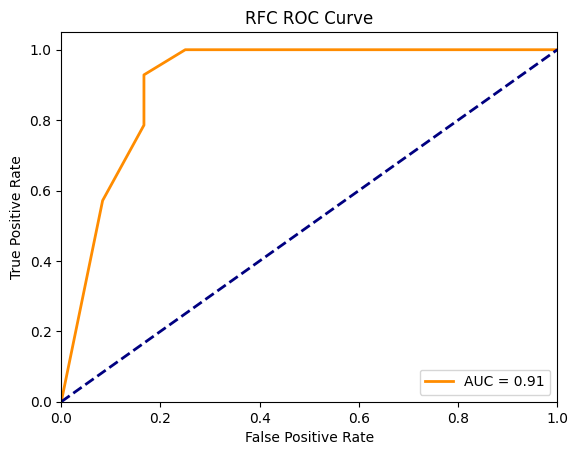

AUC: 0.91


In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Obtener las probabilidades de predicción para la clase positiva
y_pred_proba = arbol_senos.predict_proba(X_test)[:, 1]

# Calcular la curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# Calcular el área bajo la curva ROC
roc_auc = auc(fpr, tpr)

# Graficar la curva ROC
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('RFC ROC Curve')
plt.legend(loc="lower right")
plt.show()

# Imprimir el AUC
print('AUC: %.2f' % roc_auc)